# Pipeline 04: End-to-End Inference Demo

**Goal:** Demonstrate the complete product loop on YOUR photos:
1. Load a raw image from your dataset
2. SAM segments it and labels regions
3. Apply your learned style profile (per-region, with tone curves + HSL mixer)
4. Optionally layer natural language overrides
5. Display before/after

**This is the notebook that proves the pipeline works.** No stock photos, no placeholders.

**Depends on:** Pipelines 01-03, `shared.py`

**Runtime:** GPU required (SAM inference).

In [2]:
# Setup
from google.colab import drive
drive.mount('/content/drive')

PROJECT = '/content/drive/MyDrive/photo-style-rl'

!pip install anthropic git+https://github.com/ChaoningZhang/MobileSAM.git opencv-python-headless kornia -q

import shutil
shutil.copy(f'{PROJECT}/src/shared.py', '/content/shared.py')

import os, json, torch, cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import userdata
from anthropic import Anthropic
from mobile_sam import sam_model_registry, SamAutomaticMaskGenerator

from shared import (
    PROJECT, RAW_DIR, EDITED_DIR, CHECKPOINTS_DIR,
    pair_files, image_to_base64, extract_json, resize_for_sam,
    DeterministicRenderer, segment_and_label, apply_regional_edits,
    feather_mask, get_mask_properties, classify_mask_heuristic,
    visualize_segments, show_before_after, merge_params, load_style_profile,
    AVAILABLE_REGIONS
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
client = Anthropic(api_key=userdata.get('ANTHROPIC_API_KEY'))

# Load SAM
SAM_CHECKPOINT = f'{CHECKPOINTS_DIR}/mobile_sam.pt'
if not os.path.exists(SAM_CHECKPOINT):
    print('Downloading MobileSAM checkpoint (~38MB)...')
    import urllib.request
    urllib.request.urlretrieve(
        'https://huggingface.co/dhkim2810/MobileSAM/resolve/main/mobile_sam.pt',
        SAM_CHECKPOINT
    )
    print('Done.')
sam = sam_model_registry['vit_t'](checkpoint=SAM_CHECKPOINT).to(device)
auto_generator = SamAutomaticMaskGenerator(
    sam, points_per_side=32, pred_iou_thresh=0.86,
    stability_score_thresh=0.92, min_mask_region_area=0,
)

# Load ALL style profiles
advanced_profile = load_style_profile('simon_advanced_color_profile.json')
math_profile = load_style_profile('simon_math_profile.json')

# Load mask cache
CACHE_PATH = f'{CHECKPOINTS_DIR}/mask_labels_cache.json'
mask_cache = json.loads(open(CACHE_PATH).read()) if os.path.exists(CACHE_PATH) else {}

renderer = DeterministicRenderer()
pairs = pair_files()

print(f"Pipeline ready: {len(pairs)} pairs, {len(advanced_profile)} profiled regions")
print(f"Profiled regions: {list(advanced_profile.keys())}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  Preparing metadata (setup.py) ... done
Pipeline ready: 287 pairs, 12 profiled regions
Profiled regions: ['ground', 'subject', 'sky', 'background', 'highlight_area', 'clothing', 'building', 'shadow_area', 'hair', 'foliage', 'face', 'water']


In [3]:
def run_inference(pil_img, prompt="", image_id=None):
    """
    The complete product experience:
    1. Segment with SAM
    2. Apply per-region style profile (advanced tone curves + HSL mixer)
    3. Layer basic math profile on top for any regions not in advanced_profile
    4. Parse and apply text overrides if provided

    Returns: (result_pil, segments, applied_params_summary)
    """
    # 1. Segment
    print("  1. Segmenting with SAM...")
    segments = segment_and_label(
        pil_img, auto_generator, client,
        cache=mask_cache, image_id=image_id,
    )
    labels = list(set(s['label'] for s in segments))
    print(f"     Found: {labels}")

    # 2+3. Build regional_edits list from detected labels + matched profiles.
    # apply_regional_edits() handles mask building, feathering, and blending internally.
    print("  2. Applying learned style profile per region...")
    profile_edits = []
    applied = {}
    seen = set()
    for seg in segments:
        label = seg['label']
        if label in seen:
            continue  # duplicate label — apply_regional_edits unions the masks
        seen.add(label)
        if label in advanced_profile:
            profile_edits.append({'region': label, 'params': advanced_profile[label]})
            applied[label] = 'advanced'
        elif label in math_profile:
            region_params = math_profile[label].get('parameters', {})
            if region_params:
                profile_edits.append({'region': label, 'params': region_params})
                applied[label] = 'math'

    # strength=0.6: extracted profile values tend to overshoot Lightroom's internal curves
    result_pil = apply_regional_edits(pil_img, segments, profile_edits, renderer, strength=0.6)
    print(f"     Applied profiles: {applied}")

    # 4. Text override: parse prompt → flat region dict → apply at full strength.
    # Claude chose these values intentionally, so we don't dampen them.
    if prompt.strip():
        print(f"  3. Parsing override: \"{prompt}\"")
        response = client.messages.create(
            model="claude-sonnet-4-20250514",
            max_tokens=500,
            system=f"""Translate photo editing instructions into JSON overrides.
Available regions: {labels}
Output ONLY JSON where each top-level key is a region name or \"global\":
{{\"global\": {{\"exposure\": num, \"tone_curve\": {{}}, \"color_mixer\": {{}}, ...}}, \"sky\": {{...}}}}
Supported basic keys: exposure [-5,5], contrast, highlights, shadows, whites, blacks,
temperature, tint, clarity, vibrance, saturation, texture, dehaze [-100,100].""",
            messages=[{"role": "user", "content": prompt}],
        )
        overrides = extract_json(response.content[0].text) or {}
        override_edits = [{'region': r, 'params': p} for r, p in overrides.items()]
        # strength=1.0: text overrides are intentional, full-strength
        result_pil = apply_regional_edits(result_pil, segments, override_edits, renderer, strength=1.0)

    return result_pil, segments, applied


print("run_inference() ready — uses real SAM + real profiles + real masks.")


run_inference() ready — uses real SAM + real profiles + real masks.


In [4]:
# Test on 4 images from your actual dataset
test_indices = [0, len(pairs)//4, len(pairs)//2, 3*len(pairs)//4]

fig, axes = plt.subplots(len(test_indices), 3, figsize=(18, 6*len(test_indices)))

for row, idx in enumerate(test_indices):
    raw_f, edited_f = pairs[idx]

    raw_img = Image.open(os.path.join(RAW_DIR, raw_f)).convert('RGB')
    raw_resized = resize_for_sam(raw_img)

    print(f"\n{'='*60}")
    print(f"Image {row+1}: {raw_f}")

    result, segs, applied = run_inference(raw_resized, image_id=raw_f)

    axes[row, 0].imshow(raw_resized)
    axes[row, 0].set_title(f'Raw: {raw_f}', fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(result)
    axes[row, 1].set_title(f'Auto-Styled ({", ".join(applied.keys())})', fontsize=9)
    axes[row, 1].axis('off')

    your_edit = Image.open(os.path.join(EDITED_DIR, edited_f)).convert('RGB')
    axes[row, 2].imshow(your_edit)
    axes[row, 2].set_title(f'Your Edit: {edited_f}', fontsize=9)
    axes[row, 2].axis('off')

plt.suptitle('Auto-Style (Learned Profile + SAM) vs Your Lightroom Edits', fontsize=14)
plt.tight_layout()
plt.show()

# Save cache
with open(CACHE_PATH, 'w') as f:
    json.dump(mask_cache, f, indent=2)

Output hidden; open in https://colab.research.google.com to view.


Run 1: Base Profile
  1. Segmenting with SAM...
     Found: ['ground', 'background', 'highlight_area', 'clothing', 'subject']
  2. Applying learned style profile per region...
     Applied profiles: {'ground': 'advanced', 'subject': 'advanced', 'background': 'advanced', 'highlight_area': 'advanced', 'clothing': 'advanced'}

Run 2: "make the sky much cooler and more vivid"
  1. Segmenting with SAM...
     Found: ['ground', 'background', 'highlight_area', 'clothing', 'subject']
  2. Applying learned style profile per region...
     Applied profiles: {'ground': 'advanced', 'subject': 'advanced', 'background': 'advanced', 'highlight_area': 'advanced', 'clothing': 'advanced'}
  3. Parsing override: "make the sky much cooler and more vivid"

Run 3: "warm up the subject and crush the blacks globally"
  1. Segmenting with SAM...
     Found: ['ground', 'background', 'highlight_area', 'clothing', 'subject']
  2. Applying learned style profile per region...
     Applied profiles: {'ground': 'adv

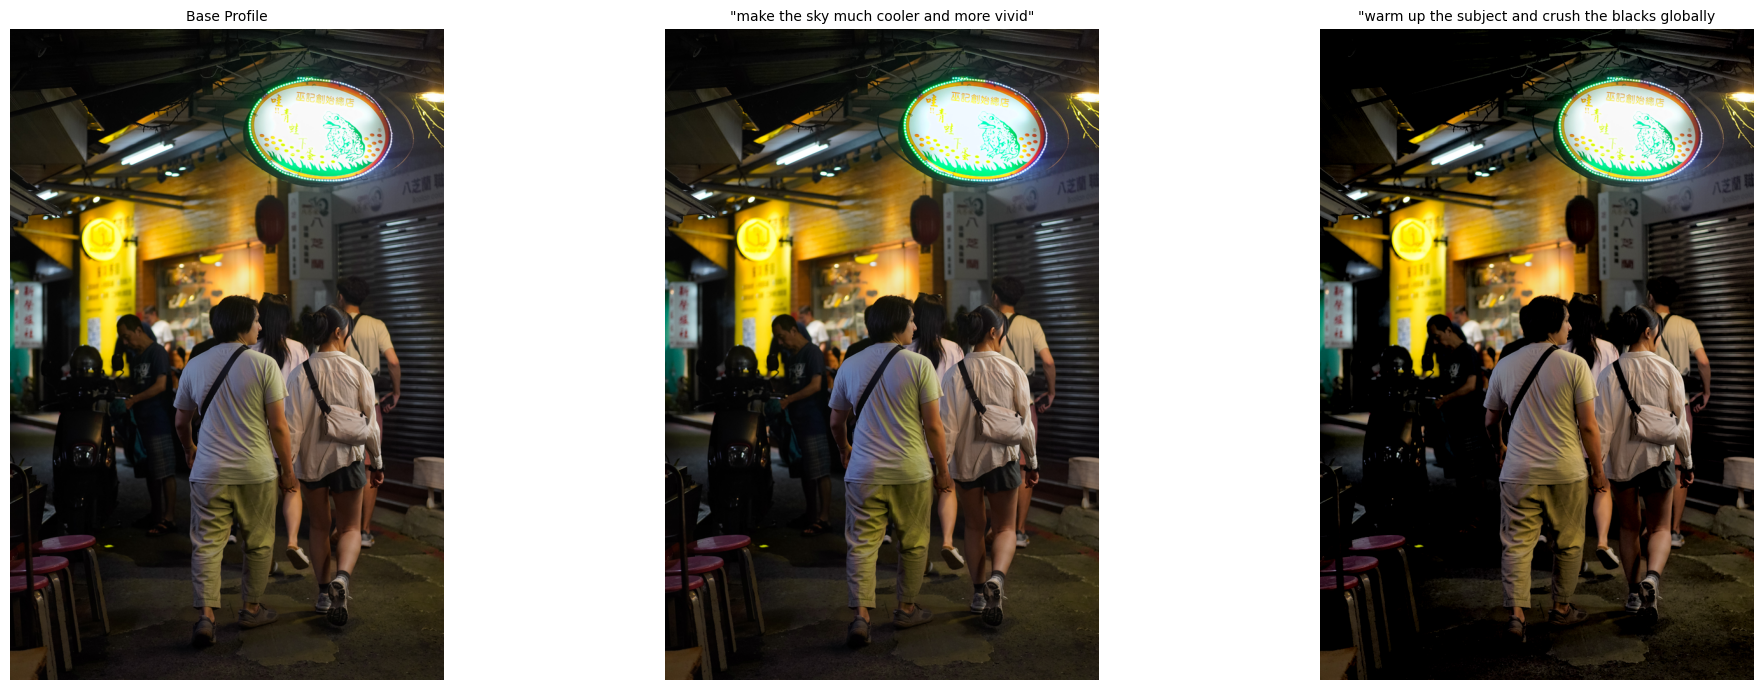


Pipeline 04 complete. Next: Pipeline 05 (Interactive UI)


In [5]:
# Test text overrides on top of auto-style
raw_f, edited_f = pairs[0]
raw_img = resize_for_sam(Image.open(os.path.join(RAW_DIR, raw_f)).convert('RGB'))

override_prompts = [
    "",  # base profile only
    "make the sky much cooler and more vivid",
    "warm up the subject and crush the blacks globally",
]

fig, axes = plt.subplots(1, len(override_prompts), figsize=(7*len(override_prompts), 7))
for i, prompt in enumerate(override_prompts):
    label = "Base Profile" if not prompt else f'"{prompt}"'
    print(f"\nRun {i+1}: {label}")
    result, _, _ = run_inference(raw_img, prompt=prompt, image_id=raw_f)
    axes[i].imshow(result)
    axes[i].set_title(label[:50], fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print("\nPipeline 04 complete. Next: Pipeline 05 (Interactive UI)")